In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None

In [2]:
train = pd.read_csv('/kaggle/input/strike-the-balance/data-2.csv')
train.head()

,x0,x1,x2,x3,x4,x5,x6,x7,y
0,-1.174897,-1.833210,1.204898,0.452466,-0.975270,-0.081187,-1.714702,0.751632,E
1,0.366575,1.222587,0.449920,-1.656913,1.042426,1.725458,0.389266,-0.740909,E
2,-1.311092,-1.391259,1.072402,0.533957,-1.940287,0.067985,-0.456627,-0.411767,C
3,-0.742921,1.345351,1.299280,-1.626808,3.924320,1.781546,2.368074,0.479126,B
4,0.668799,1.740830,-0.865123,-1.555816,-0.324223,-0.225153,1.280064,-0.565775,B


In [3]:
test = pd.read_csv('/kaggle/input/strike-the-balance/test_data.csv')
test.head()

,Id,x0,x1,x2,x3,x4,x5,x6,x7
0,1000001,4.429612,-1.461394,1.193939,0.153088,0.966728,-2.093609,1.570052,-1.949796
1,1000002,-0.092503,1.949938,-1.490157,-0.654477,-0.342993,-0.605460,1.699396,-0.387801
2,1000003,1.631302,-1.407682,1.243291,-1.985504,1.708704,-2.063432,0.613715,0.283075
3,1000004,-3.435034,4.040238,0.766683,-2.738580,1.576753,0.202948,1.509603,1.050538
4,1000005,-1.401045,0.762346,-1.122744,4.543637,-0.833333,2.962153,1.800574,-0.327866


In [4]:
combined = pd.concat([train,test])
combined.head()

,x0,x1,x2,x3,x4,x5,x6,x7,y,Id
0,-1.174897,-1.833210,1.204898,0.452466,-0.975270,-0.081187,-1.714702,0.751632,E,NaN
1,0.366575,1.222587,0.449920,-1.656913,1.042426,1.725458,0.389266,-0.740909,E,NaN
2,-1.311092,-1.391259,1.072402,0.533957,-1.940287,0.067985,-0.456627,-0.411767,C,NaN
3,-0.742921,1.345351,1.299280,-1.626808,3.924320,1.781546,2.368074,0.479126,B,NaN
4,0.668799,1.740830,-0.865123,-1.555816,-0.324223,-0.225153,1.280064,-0.565775,B,NaN


In [6]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 45000 entries, 0 to 8999
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x0      45000 non-null  float64
 1   x1      45000 non-null  float64
 2   x2      45000 non-null  float64
 3   x3      45000 non-null  float64
 4   x4      45000 non-null  float64
 5   x5      45000 non-null  float64
 6   x6      45000 non-null  float64
 7   x7      45000 non-null  float64
 8   y       36000 non-null  object 
 9   Id      9000 non-null   float64
dtypes: float64(9), object(1)
memory usage: 3.8+ MB


In [7]:
combined.dtypes

x0    float64
x1    float64
x2    float64
x3    float64
x4    float64
x5    float64
x6    float64
x7    float64
y      object
Id    float64
dtype: object

In [9]:
combined.isnull().sum()/len(combined)*100

x0     0.0
x1     0.0
x2     0.0
x3     0.0
x4     0.0
x5     0.0
x6     0.0
x7     0.0
y     20.0
Id    80.0
dtype: float64

In [10]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
x0,45000.0,1.045379e-01,1.580183,-5.078564e+00,-1.080875e+00,-2.381573e-01,1.199488e+00,7.451936e+00
x1,45000.0,8.606402e-01,1.472051,-5.011481e+00,-1.424543e-01,8.691087e-01,1.863979e+00,7.095376e+00
x2,45000.0,-2.378376e-03,1.000364,-4.251364e+00,-6.751293e-01,-1.075406e-02,6.699598e-01,3.826255e+00
x3,45000.0,-2.002992e-01,1.586001,-5.243831e+00,-1.294456e+00,-5.400494e-01,6.371803e-01,7.780009e+00
x4,45000.0,1.605282e-01,1.665653,-6.216766e+00,-1.009510e+00,1.295928e-01,1.332929e+00,6.966287e+00
x5,45000.0,-1.474046e-03,1.004563,-4.004546e+00,-6.825789e-01,2.872157e-03,6.761197e-01,3.918185e+00
x6,45000.0,7.954757e-01,1.113514,-5.449612e+00,1.742396e-01,8.874952e-01,1.535845e+00,4.807943e+00
x7,45000.0,-9.652108e-01,1.263854,-7.187877e+00,-1.720414e+00,-9.762156e-01,-2.246491e-01,5.715269e+00
Id,9000.0,1.004500e+06,2598.220545,1.000001e+06,1.002251e+06,1.004500e+06,1.006750e+06,1.009000e+06


In [12]:
combined.shape

(45000, 10)

<Axes: >

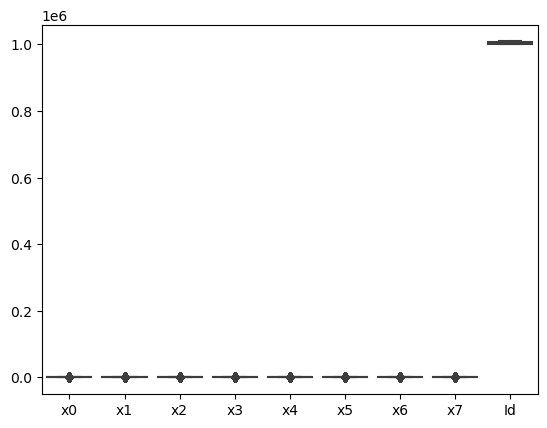

In [13]:
sns.boxplot(combined)

<Axes: >

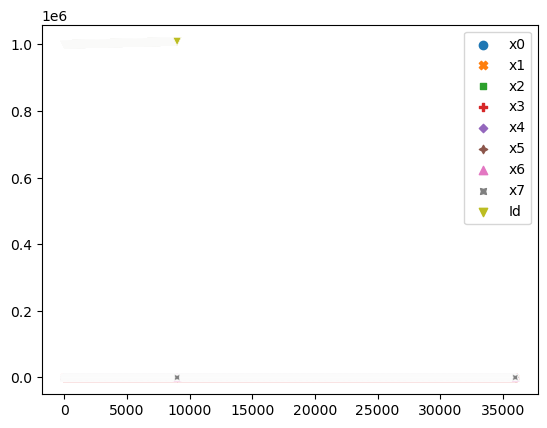

In [14]:
sns.scatterplot(combined)

<Axes: >

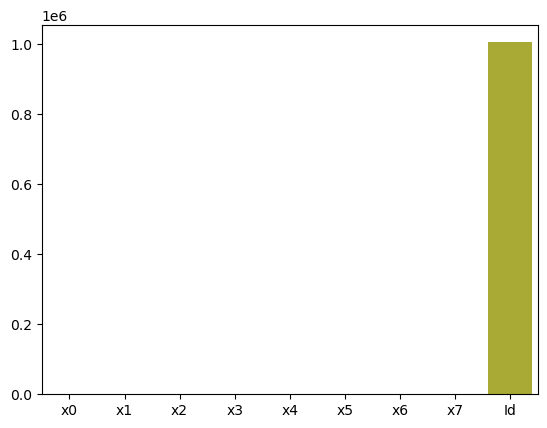

In [15]:
sns.barplot(combined)

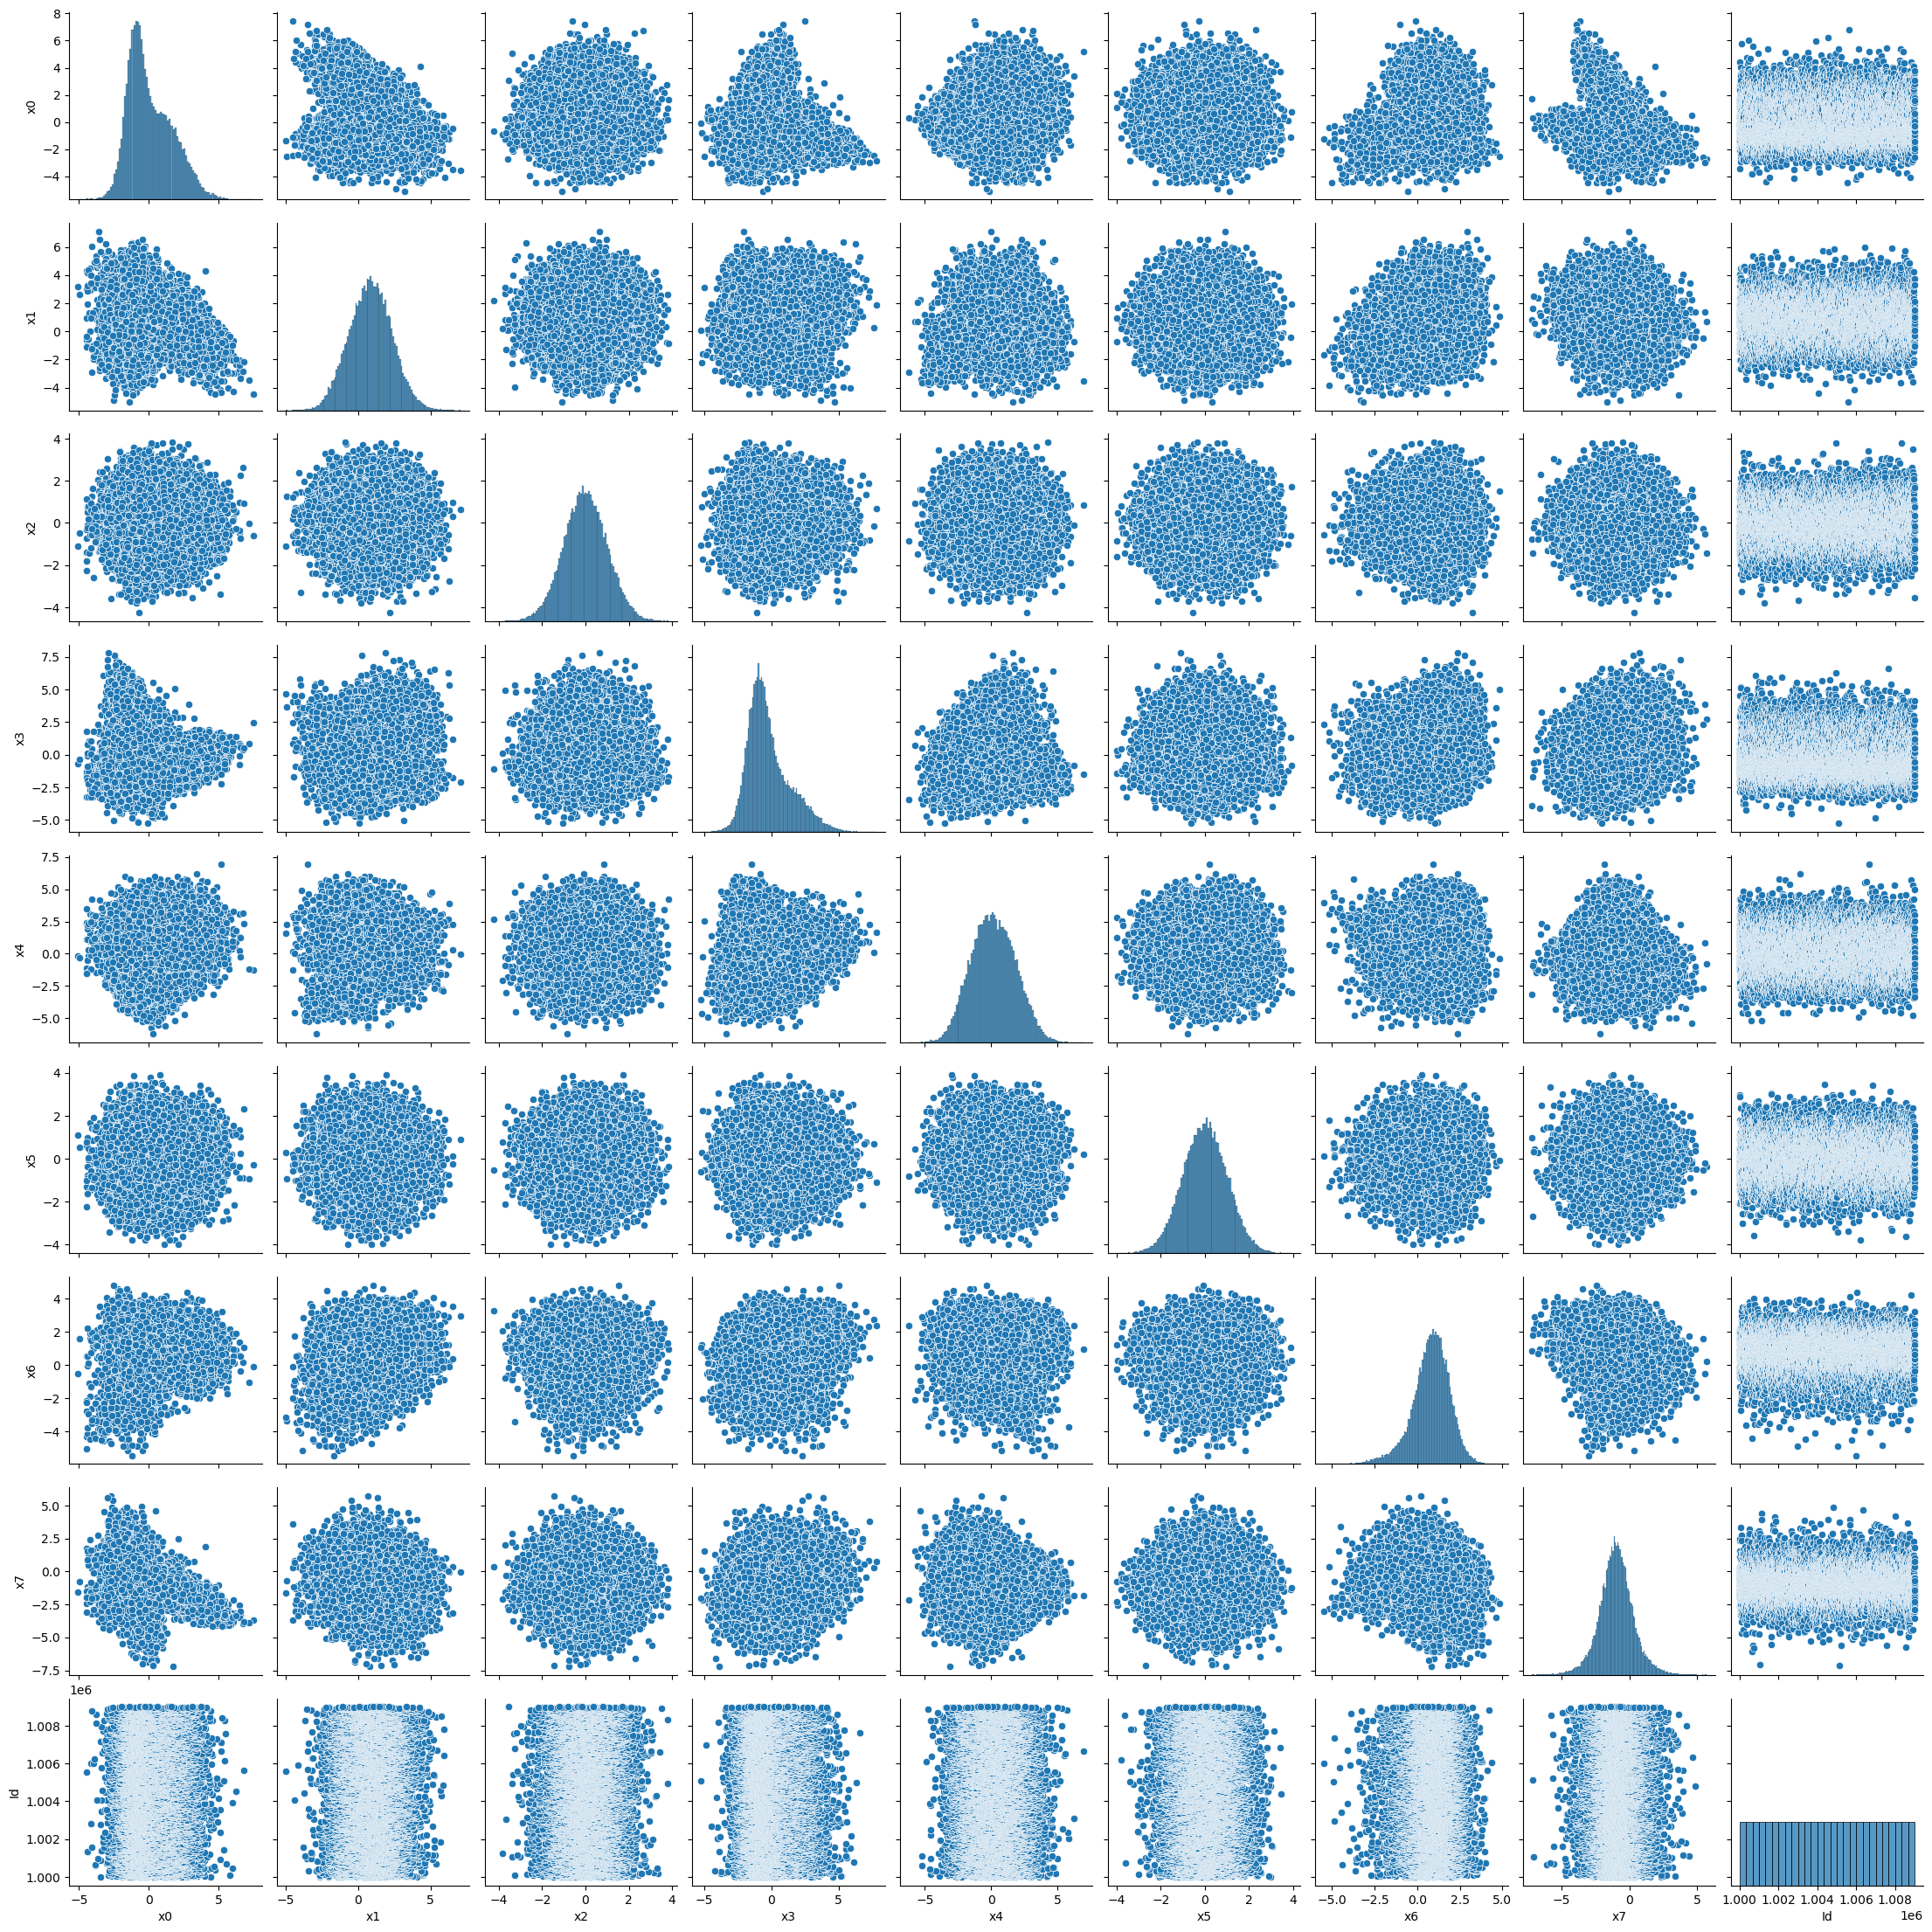

In [18]:
sns.pairplot(combined)

<Axes: ylabel='Density'>

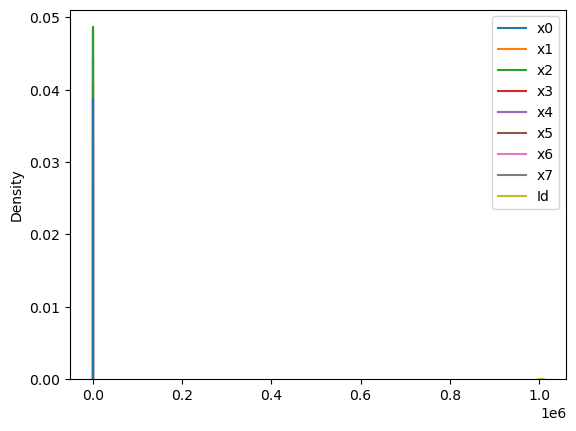

In [19]:
sns.kdeplot(combined)

In [20]:
combined.skew()

/tmp/ipykernel_32/3158812268.py:1: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined.skew()


x0    0.600458
x1    0.005453
x2    0.006886
x3    0.863898
x4    0.059776
x5   -0.020645
x6   -0.657754
x7    0.051628
Id    0.000000
dtype: float64

In [21]:
combined.kurt()

/tmp/ipykernel_32/292944781.py:1: FutureWarning: The default value of numeric_only in DataFrame.kurt is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined.kurt()


x0   -0.093105
x1   -0.058696
x2    0.016730
x3    0.676429
x4   -0.259855
x5    0.001215
x6    1.220790
x7    1.165855
Id   -1.200000
dtype: float64

/tmp/ipykernel_32/1658940522.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True)


<Axes: >

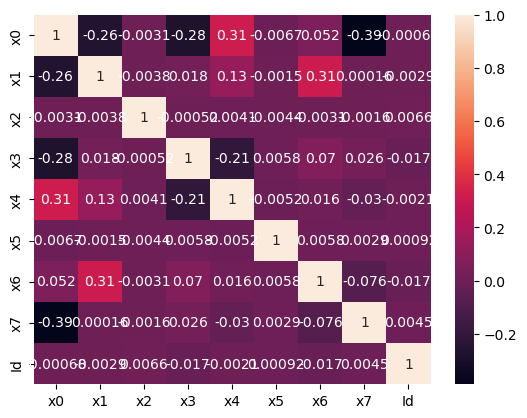

In [22]:
sns.heatmap(combined.corr(),annot=True)

In [23]:
cat_cols = combined.select_dtypes(include='object')

In [24]:
for i in cat_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

y
B    19661
A    12561
C     1856
D     1140
E      782
Name: y, dtype: int64
__________________________________________________


In [26]:
num_cols = combined.select_dtypes(include='number')

In [27]:
for i in num_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

x0
-1.174897    1
-0.015489    1
-0.151072    1
-0.054798    1
-0.780995    1
            ..
-1.490300    1
-1.057728    1
 2.519722    1
-3.249974    1
-0.263534    1
Name: x0, Length: 45000, dtype: int64
__________________________________________________
x1
-1.833210    1
 2.121540    1
-0.236693    1
 0.226832    1
 2.408374    1
            ..
 3.042283    1
-1.115710    1
 0.717801    1
 3.116189    1
 1.485988    1
Name: x1, Length: 45000, dtype: int64
__________________________________________________
x2
 1.204898    1
 0.864162    1
 0.071778    1
 1.203511    1
-0.878467    1
            ..
-2.113823    1
 0.909828    1
 1.075468    1
-1.236399    1
 0.353717    1
Name: x2, Length: 45000, dtype: int64
__________________________________________________
x3
 0.452466    1
-2.024842    1
 0.153437    1
-1.390294    1
-1.631024    1
            ..
 0.477630    1
 1.335880    1
-0.307561    1
-2.462816    1
 0.503467    1
Name: x3, Length: 45000, dtype: int64
_______________________

In [29]:
combined['x0']=combined['x0'].map({'Good':2,'Standard':1,'Poor':0})


/tmp/ipykernel_32/401063577.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')


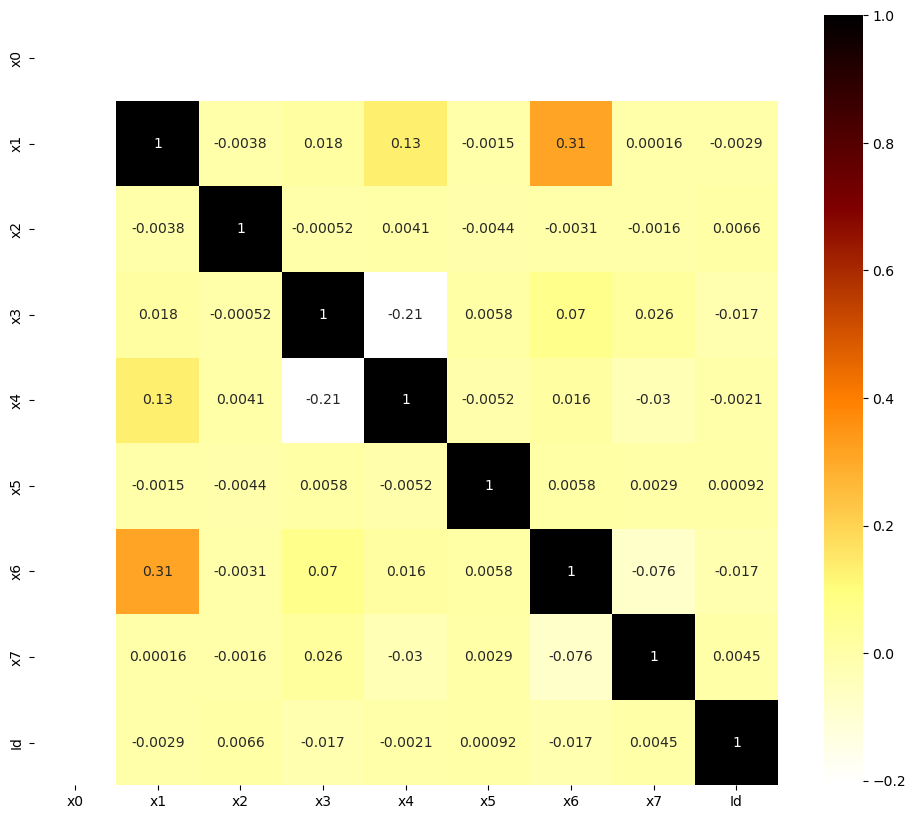

In [30]:
plt.figure(figsize=(12,10))
sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')
plt.show()

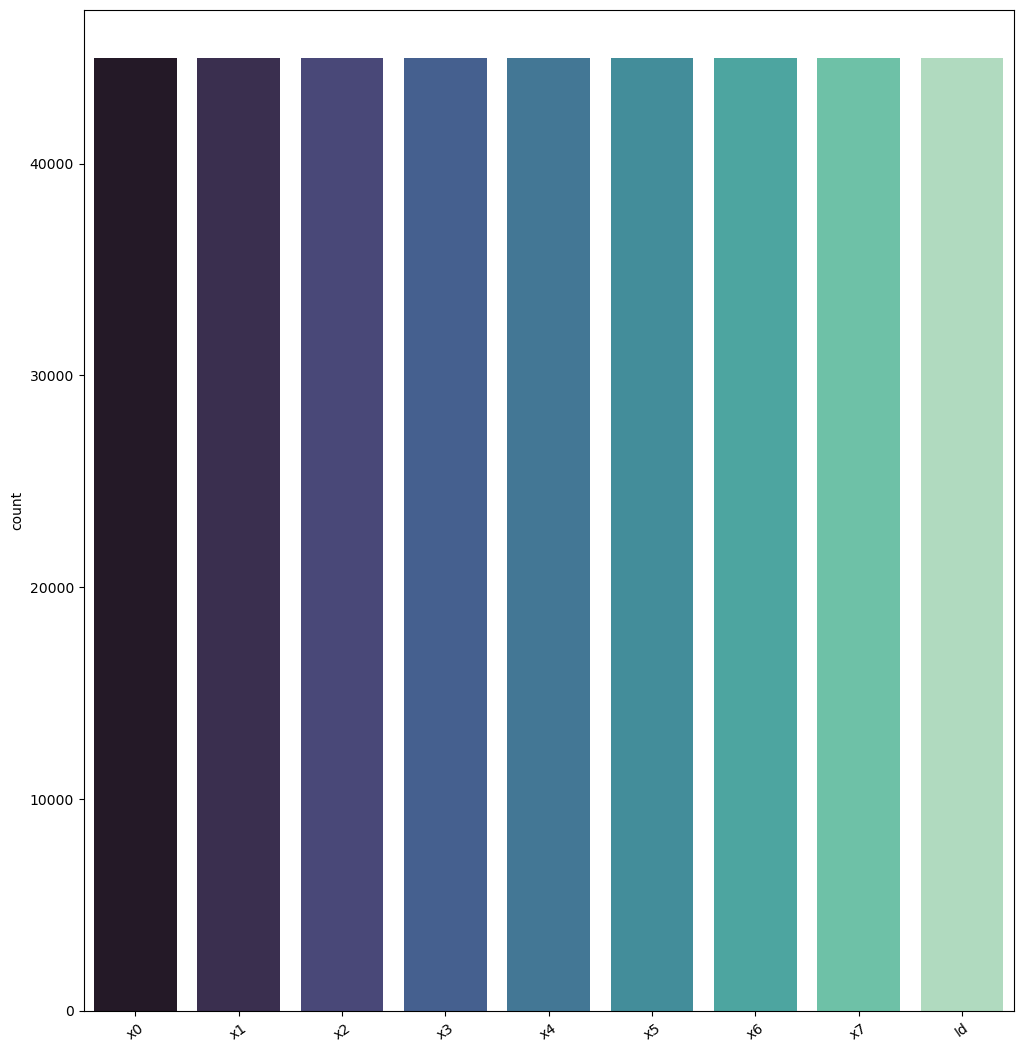

In [32]:
plt.figure(figsize=(12,13))
sns.countplot(combined,palette='mako');
plt.xticks(rotation=35);

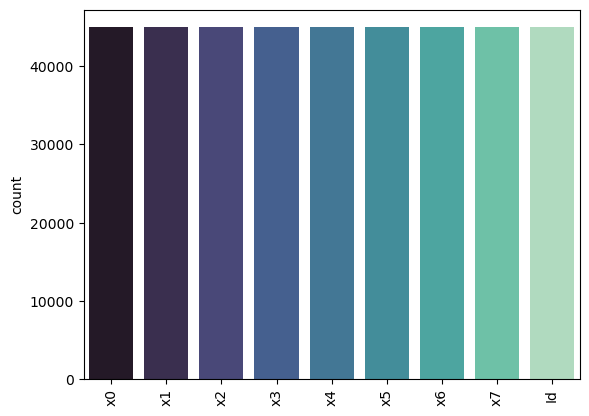

In [33]:
sns.countplot(combined,palette='mako');
plt.xticks(rotation=90);

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'x0'),
  Text(1, 0, 'x1'),
  Text(2, 0, 'x2'),
  Text(3, 0, 'x3'),
  Text(4, 0, 'x4'),
  Text(5, 0, 'x5'),
  Text(6, 0, 'x6'),
  Text(7, 0, 'x7'),
  Text(8, 0, 'Id')])

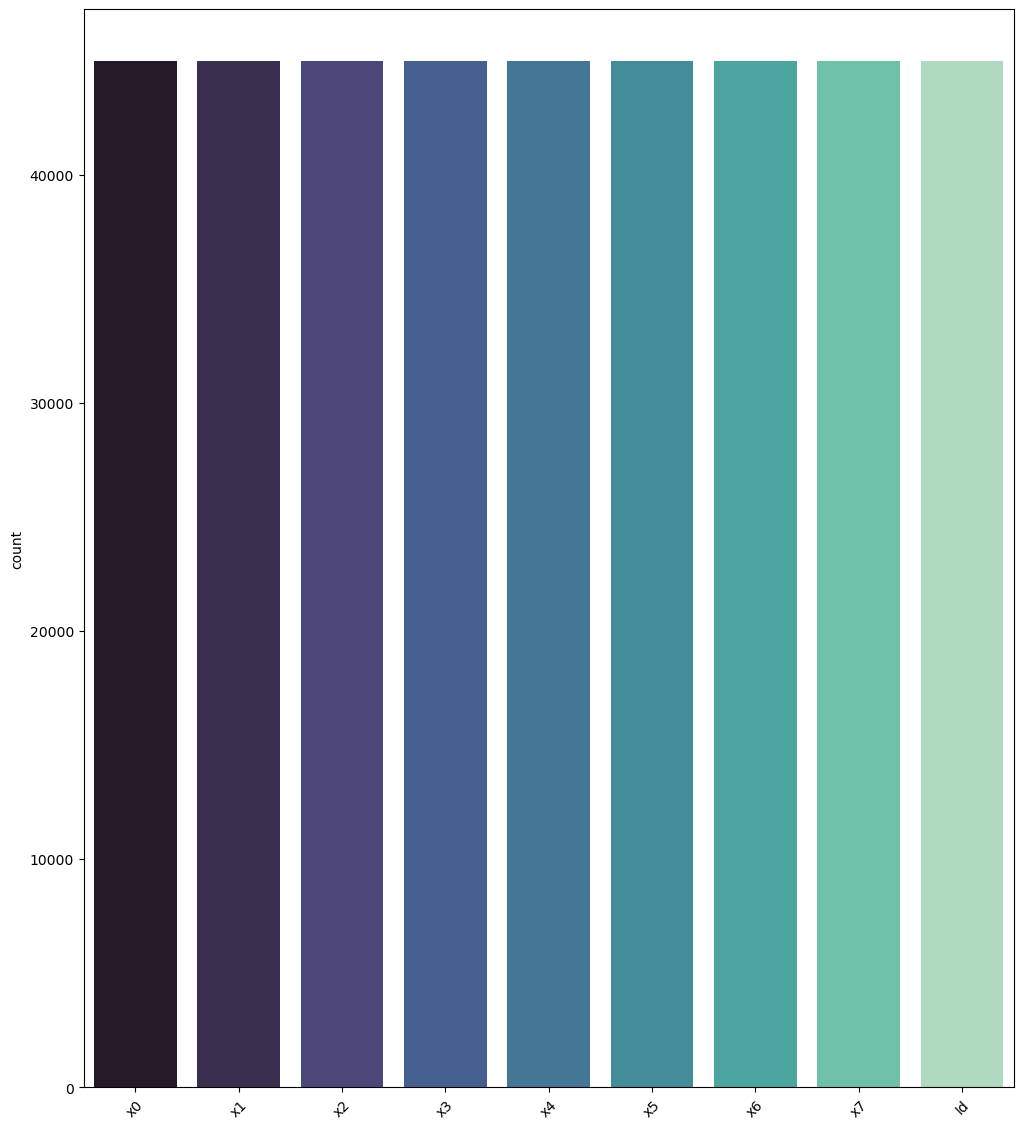

In [34]:
plt.figure(figsize=(12,14))
sns.countplot(combined,palette='mako')
plt.xticks(rotation=45)

In [35]:
combined['x0'].value_counts()

Series([], Name: x0, dtype: int64)

In [36]:
combined['x0'].unique()

array([nan])

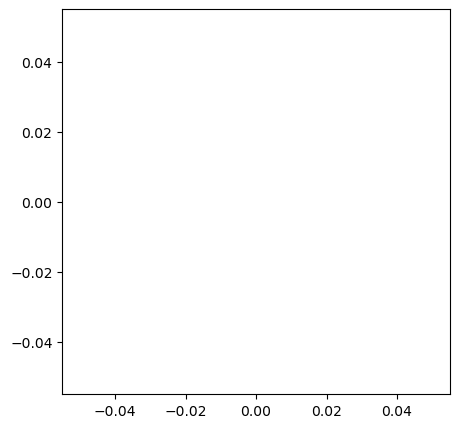

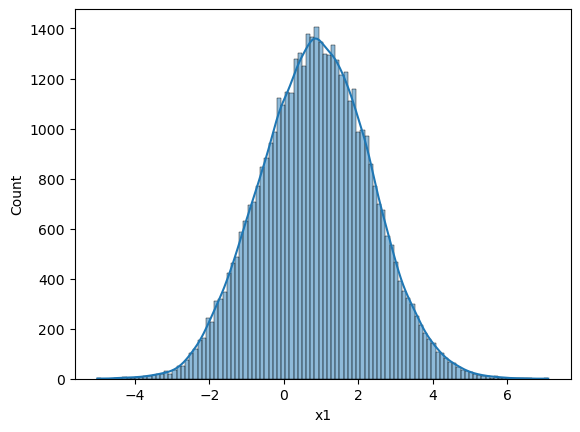

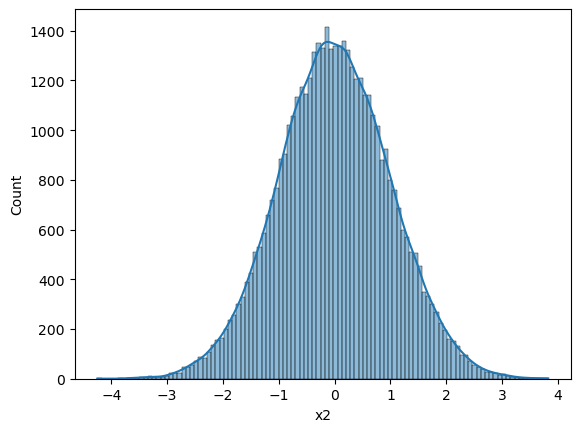

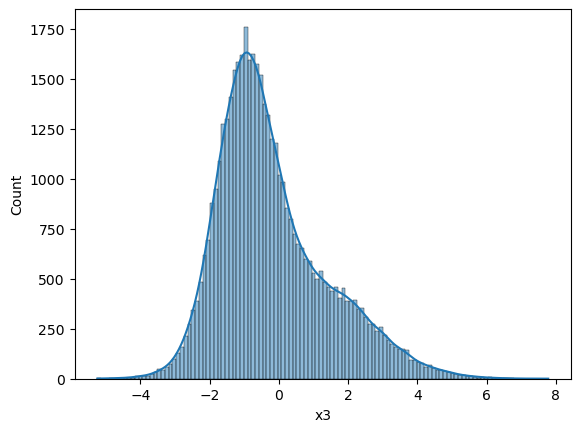

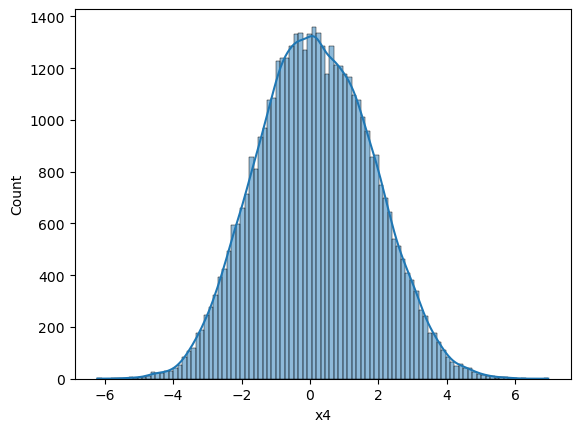

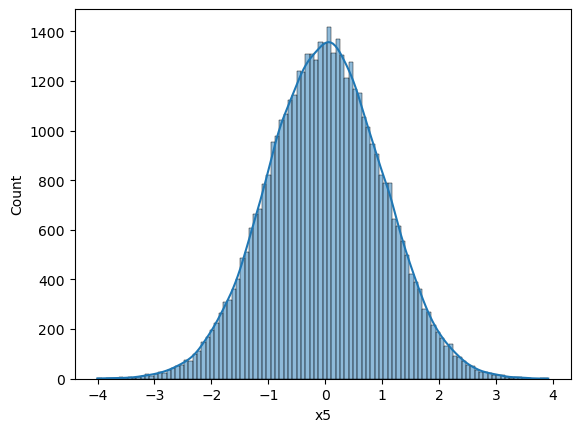

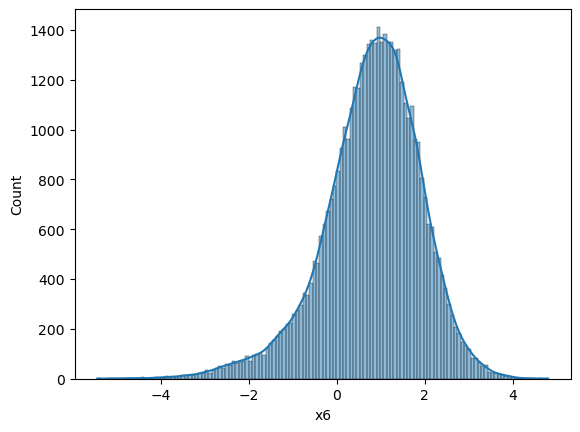

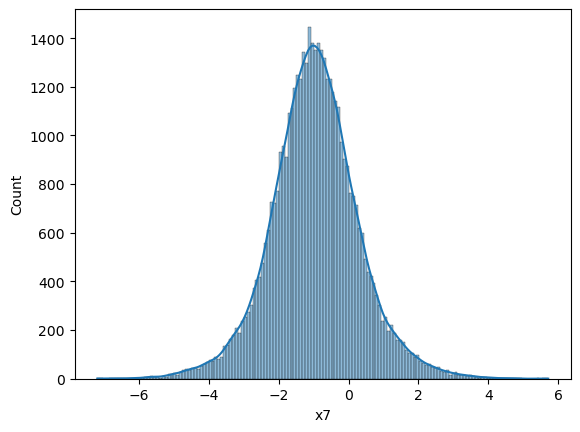

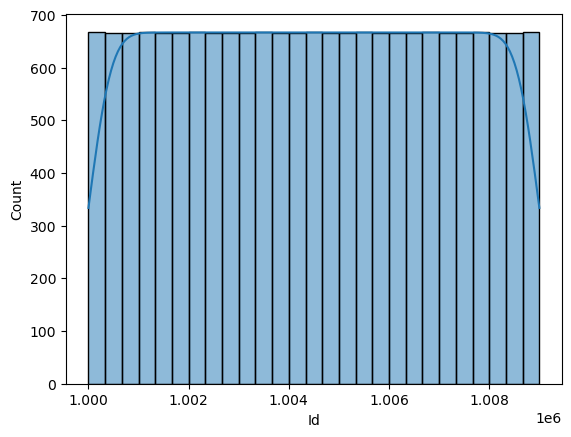

In [40]:
plt.figure(figsize=(5,5))
x=1
for i in num_cols:
    sns.histplot(data=combined,x=i,kde=True)
    print('\n')
    plt.show()

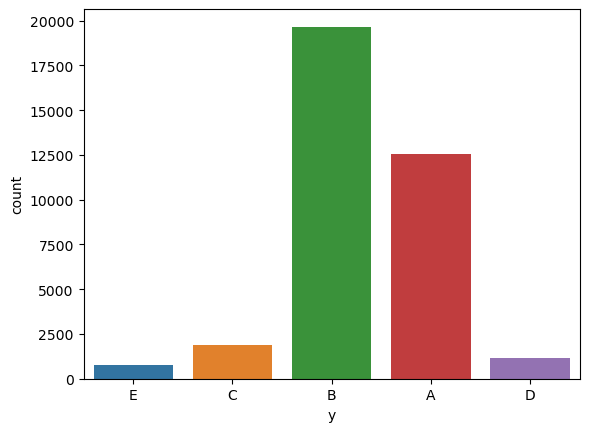

In [41]:
x=1
for i in cat_cols:
    sns.countplot(data=combined,x=i)
    print('\n')
    plt.show()

In [43]:
# Replacing weird values
combined= combined.applymap(lambda x: x if x is np.NaN or not isinstance(x,str)else str(x).strip('_,"')
                           ).replace(['','nan','!@9#%8','#F%$D@*&8'],np.NaN)

In [44]:
combined.head()

,x0,x1,x2,x3,x4,x5,x6,x7,y,Id
0,NaN,-1.833210,1.204898,0.452466,-0.975270,-0.081187,-1.714702,0.751632,E,NaN
1,NaN,1.222587,0.449920,-1.656913,1.042426,1.725458,0.389266,-0.740909,E,NaN
2,NaN,-1.391259,1.072402,0.533957,-1.940287,0.067985,-0.456627,-0.411767,C,NaN
3,NaN,1.345351,1.299280,-1.626808,3.924320,1.781546,2.368074,0.479126,B,NaN
4,NaN,1.740830,-0.865123,-1.555816,-0.324223,-0.225153,1.280064,-0.565775,B,NaN


In [49]:
# Treating type of x1
combined['y'].value_counts().head(9).index[1:]

Index(['A', 'C', 'D', 'E'], dtype='object')

In [48]:
# Rebuild type of x1 columns
for i in combined['y'].value_counts().head(9).index[1:]:
    combined[i]=combined['y'].str.contains(i)

In [50]:
combined.head()

,x0,x1,x2,x3,x4,x5,x6,x7,y,Id,A,C,D,E
0,NaN,-1.833210,1.204898,0.452466,-0.975270,-0.081187,-1.714702,0.751632,E,NaN,False,False,False,True
1,NaN,1.222587,0.449920,-1.656913,1.042426,1.725458,0.389266,-0.740909,E,NaN,False,False,False,True
2,NaN,-1.391259,1.072402,0.533957,-1.940287,0.067985,-0.456627,-0.411767,C,NaN,False,True,False,False
3,NaN,1.345351,1.299280,-1.626808,3.924320,1.781546,2.368074,0.479126,B,NaN,False,False,False,False
4,NaN,1.740830,-0.865123,-1.555816,-0.324223,-0.225153,1.280064,-0.565775,B,NaN,False,False,False,False


In [51]:
mapping = combined.groupby('x0')['x1'].mean().to_dict()

In [52]:
combined['x1']=combined['x0'].map(mapping)

In [53]:
combined['x1']=round(combined['x1'],0)

In [55]:
combined['x1']=combined['x1'].astype(str)

In [56]:
combined.head()

,x0,x1,x2,x3,x4,x5,x6,x7,y,Id,A,C,D,E
0,NaN,nan,1.204898,0.452466,-0.975270,-0.081187,-1.714702,0.751632,E,NaN,False,False,False,True
1,NaN,nan,0.449920,-1.656913,1.042426,1.725458,0.389266,-0.740909,E,NaN,False,False,False,True
2,NaN,nan,1.072402,0.533957,-1.940287,0.067985,-0.456627,-0.411767,C,NaN,False,True,False,False
3,NaN,nan,1.299280,-1.626808,3.924320,1.781546,2.368074,0.479126,B,NaN,False,False,False,False
4,NaN,nan,-0.865123,-1.555816,-0.324223,-0.225153,1.280064,-0.565775,B,NaN,False,False,False,False


In [58]:
combined.isnull().sum()

x0    45000
x1        0
x2        0
x3        0
x4        0
x5        0
x6        0
x7        0
y      9000
Id    36000
A      9000
C      9000
D      9000
E      9000
dtype: int64

In [59]:
combined['x1'].value_counts()

nan    45000
Name: x1, dtype: int64

In [60]:
# Treating type of x2
combined.groupby('x0')['x2'].apply(lambda x:x.fillna(x.mode()[0]))

/tmp/ipykernel_32/3932439873.py:2: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  combined.groupby('x0')['x2'].apply(lambda x:x.fillna(x.mode()[0]))


Series([], Name: x2, dtype: float64)

In [61]:
map1 = combined.groupby(['x0'])['x3'].agg(pd.Series.mode).to_dict()

In [62]:
combined['x3']=combined['x3'].map(map1)

In [63]:
combined['x3'].isnull().sum()

45000

In [65]:
combined.head()

,x0,x1,x2,x3,x4,x5,x6,x7,y,Id,A,C,D,E
0,NaN,nan,1.204898,NaN,-0.975270,-0.081187,-1.714702,0.751632,E,NaN,False,False,False,True
1,NaN,nan,0.449920,NaN,1.042426,1.725458,0.389266,-0.740909,E,NaN,False,False,False,True
2,NaN,nan,1.072402,NaN,-1.940287,0.067985,-0.456627,-0.411767,C,NaN,False,True,False,False
3,NaN,nan,1.299280,NaN,3.924320,1.781546,2.368074,0.479126,B,NaN,False,False,False,False
4,NaN,nan,-0.865123,NaN,-0.324223,-0.225153,1.280064,-0.565775,B,NaN,False,False,False,False


In [66]:
# Treating type of x4
combined['x4'].isnull().sum()

0

In [68]:
map2 = combined.groupby(['x0'])['x4'].mean().to_dict()

In [69]:
combined['x4']=combined['x4'].map(map2)

In [71]:
combined['x4'].isnull().sum()

45000

In [73]:
combined.head()

,x0,x1,x2,x3,x4,x5,x6,x7,y,Id,A,C,D,E
0,NaN,nan,1.204898,NaN,NaN,-0.081187,-1.714702,0.751632,E,NaN,False,False,False,True
1,NaN,nan,0.449920,NaN,NaN,1.725458,0.389266,-0.740909,E,NaN,False,False,False,True
2,NaN,nan,1.072402,NaN,NaN,0.067985,-0.456627,-0.411767,C,NaN,False,True,False,False
3,NaN,nan,1.299280,NaN,NaN,1.781546,2.368074,0.479126,B,NaN,False,False,False,False
4,NaN,nan,-0.865123,NaN,NaN,-0.225153,1.280064,-0.565775,B,NaN,False,False,False,False


In [74]:
# Treating type of x5  with the help of x0
combined['x5']=combined['x5'].astype(float)

In [77]:
map3 = combined.groupby('x0')['x5'].median().to_dict()

In [78]:
combined['x5']=combined['x0'].map(map3)

In [79]:
combined['x5']=round(combined['x0'],0)

In [80]:
combined.head()

,x0,x1,x2,x3,x4,x5,x6,x7,y,Id,A,C,D,E
0,NaN,nan,1.204898,NaN,NaN,NaN,-1.714702,0.751632,E,NaN,False,False,False,True
1,NaN,nan,0.449920,NaN,NaN,NaN,0.389266,-0.740909,E,NaN,False,False,False,True
2,NaN,nan,1.072402,NaN,NaN,NaN,-0.456627,-0.411767,C,NaN,False,True,False,False
3,NaN,nan,1.299280,NaN,NaN,NaN,2.368074,0.479126,B,NaN,False,False,False,False
4,NaN,nan,-0.865123,NaN,NaN,NaN,1.280064,-0.565775,B,NaN,False,False,False,False


In [81]:
# Treating null of x6 with help of x0
map4 = combined.groupby('x0')['x6'].agg(pd.Series.mode).to_dict()

In [82]:
combined['x6']=combined['x0'].map(map4)

In [83]:
combined['x7'].dtypes

dtype('float64')

In [84]:
combined.head()

,x0,x1,x2,x3,x4,x5,x6,x7,y,Id,A,C,D,E
0,NaN,nan,1.204898,NaN,NaN,NaN,NaN,0.751632,E,NaN,False,False,False,True
1,NaN,nan,0.449920,NaN,NaN,NaN,NaN,-0.740909,E,NaN,False,False,False,True
2,NaN,nan,1.072402,NaN,NaN,NaN,NaN,-0.411767,C,NaN,False,True,False,False
3,NaN,nan,1.299280,NaN,NaN,NaN,NaN,0.479126,B,NaN,False,False,False,False
4,NaN,nan,-0.865123,NaN,NaN,NaN,NaN,-0.565775,B,NaN,False,False,False,False


In [85]:
# Treatong type of x7 with help of x0
map5 = combined.groupby('x0')['x7'].mean().to_dict()

In [86]:
combined['x7']=combined['x0'].map(map5)

In [87]:
combined['x0'].isnull().sum()

45000

In [89]:
combined['x0'].value_counts()

Series([], Name: x0, dtype: int64)

In [90]:
map5 = combined.groupby('x0')['x7'].agg(pd.Series.mode).to_dict()

In [91]:
combined['x7']=combined['x0'].map(map5)